# Financial Analytics

## Assignment 2- Case Study

## Anik Basu
## 24030242006

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.utils import resample


In [ ]:
# Load the dataset
file_path = "C:/Users/asus zb/Downloads/Case Study Data.xlsx"
df = pd.read_excel(file_path, sheet_name="Complete Data")

# Display first few rows
print("\nSample Data:")
print(df.head(10))


Sample Data:
   Company ID      DSRI       GMI       AQI        SGI      DEPI      SGAI  \
0           1  1.624742  1.128927  7.185053   0.366211  1.381519  1.624145   
1           2  1.000000  1.606492  1.004988  13.081433  0.400000  5.198207   
2           3  1.000000  1.015607  1.241389   1.475018  1.169353  0.647671   
3           4  1.486239  1.000000  0.465535   0.672840  2.000000  0.092890   
4           5  1.000000  1.369038  0.637112   0.861346  1.454676  1.741460   
5           6  0.905532  1.360915  0.783995   1.793324  1.278244  0.505260   
6           7  1.447484  0.998407  0.966553   0.911809  1.058861  0.898421   
7           8  7.659976  0.580184  1.035791   1.485440  0.678833  0.653651   
8           9  1.346279  2.473563  0.702530   0.965624  0.985273  0.594511   
9          10  1.000000  1.000000  1.166638   2.592593  0.850340  0.557143   

       ACCR      LEVI Manipulater  C-MANIPULATOR  
0 -0.166809  1.161082         Yes              1  
1  0.060475  0.986732    

In [ ]:
# Removing unnecessary columns
df = df.drop(columns=['Manipulater'])
print(df.head(10))

   Company ID      DSRI       GMI       AQI        SGI      DEPI      SGAI  \
0           1  1.624742  1.128927  7.185053   0.366211  1.381519  1.624145   
1           2  1.000000  1.606492  1.004988  13.081433  0.400000  5.198207   
2           3  1.000000  1.015607  1.241389   1.475018  1.169353  0.647671   
3           4  1.486239  1.000000  0.465535   0.672840  2.000000  0.092890   
4           5  1.000000  1.369038  0.637112   0.861346  1.454676  1.741460   
5           6  0.905532  1.360915  0.783995   1.793324  1.278244  0.505260   
6           7  1.447484  0.998407  0.966553   0.911809  1.058861  0.898421   
7           8  7.659976  0.580184  1.035791   1.485440  0.678833  0.653651   
8           9  1.346279  2.473563  0.702530   0.965624  0.985273  0.594511   
9          10  1.000000  1.000000  1.166638   2.592593  0.850340  0.557143   

       ACCR      LEVI  C-MANIPULATOR  
0 -0.166809  1.161082              1  
1  0.060475  0.986732              1  
2  0.036732  1.264305   

In [ ]:
# Defining features and target variable
features = ["DSRI", "GMI", "AQI", "SGI", "DEPI", "SGAI", "ACCR", "LEVI"]
target = "C-MANIPULATOR"

# Splitting dataset into train and test sets
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Handling class imbalance
train_data = pd.concat([X_train, y_train], axis=1)
majority = train_data[train_data[target] == 0]
minority = train_data[train_data[target] == 1]

# Oversampling the minority class
minority_upsampled = resample(minority, replace=True, n_samples=len(majority), random_state=42)

# Undersampling the majority class
majority_downsampled = resample(majority, replace=False, n_samples=len(minority), random_state=42)

# Creating balanced datasets
balanced_train_oversampled = pd.concat([majority, minority_upsampled])
balanced_train_undersampled = pd.concat([majority_downsampled, minority])

# Using oversampled data for training
X_train_balanced = balanced_train_oversampled[features]
y_train_balanced = balanced_train_oversampled[target]

# Normalizing data
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

# Function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, title):
    matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Manipulator', 'Manipulator'], yticklabels=['Non-Manipulator', 'Manipulator'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

## LOGISTIC REGRESSION

Logistic Regression Accuracy: 91.94%


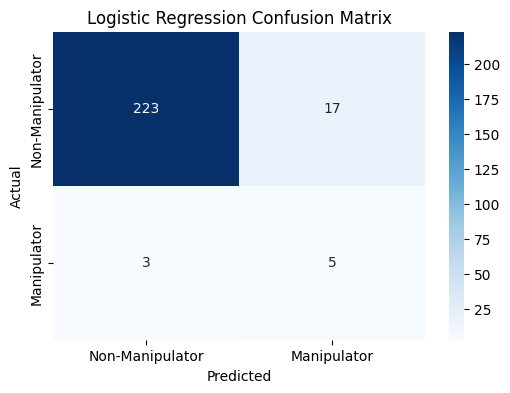

              precision    recall  f1-score   support

           0       0.99      0.93      0.96       240
           1       0.23      0.62      0.33         8

    accuracy                           0.92       248
   macro avg       0.61      0.78      0.65       248
weighted avg       0.96      0.92      0.94       248



In [ ]:
# Training and evaluating Logistic Regression
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train_balanced)
y_pred_log = log_model.predict(X_test_scaled)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_log) * 100:.2f}%")
plot_confusion_matrix(y_test, y_pred_log, "Logistic Regression Confusion Matrix")
print(classification_report(y_test, y_pred_log))

## SUPPORT VECTOR MACHINE

SVM Accuracy: 93.95%


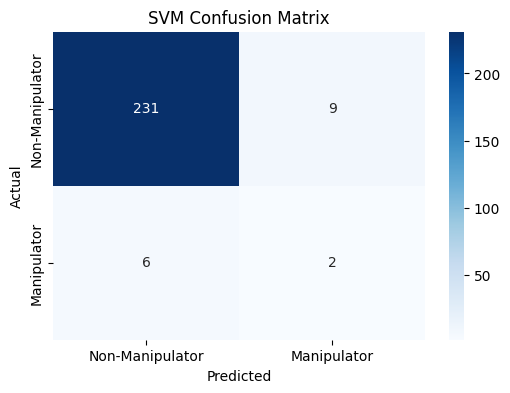

              precision    recall  f1-score   support

           0       0.97      0.96      0.97       240
           1       0.18      0.25      0.21         8

    accuracy                           0.94       248
   macro avg       0.58      0.61      0.59       248
weighted avg       0.95      0.94      0.94       248



In [ ]:
# Training and evaluating Support Vector Machine (SVM)
svm_model = SVC(kernel='linear', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train_balanced)
y_pred_svm = svm_model.predict(X_test_scaled)
print(f"SVM Accuracy: {accuracy_score(y_test, y_pred_svm) * 100:.2f}%")
plot_confusion_matrix(y_test, y_pred_svm, "SVM Confusion Matrix")
print(classification_report(y_test, y_pred_svm))

## NAIVE BAYES

Naive Bayes Accuracy: 94.35%


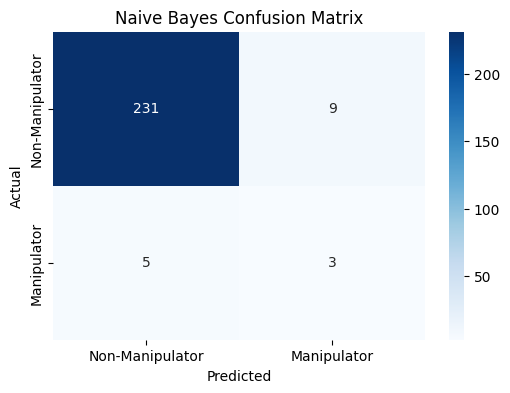

              precision    recall  f1-score   support

           0       0.98      0.96      0.97       240
           1       0.25      0.38      0.30         8

    accuracy                           0.94       248
   macro avg       0.61      0.67      0.64       248
weighted avg       0.96      0.94      0.95       248



In [ ]:
# Training and evaluating Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train_balanced)
y_pred_nb = gnb.predict(X_test_scaled)
print(f"Naive Bayes Accuracy: {accuracy_score(y_test, y_pred_nb) * 100:.2f}%")
plot_confusion_matrix(y_test, y_pred_nb, "Naive Bayes Confusion Matrix")
print(classification_report(y_test, y_pred_nb))